<a href="https://colab.research.google.com/github/Yukkitsune/TBank-Analytics/blob/main/Visualisation/Visualisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://drive.google.com/file/d/1GpwkQSXl4mPZRCMGER4PD3gNAfJUWJH5/view?usp=sharing

In [13]:
!gdown 1GpwkQSXl4mPZRCMGER4PD3gNAfJUWJH5

Downloading...
From: https://drive.google.com/uc?id=1GpwkQSXl4mPZRCMGER4PD3gNAfJUWJH5
To: /content/visualisation_df.zip
100% 6.30k/6.30k [00:00<00:00, 13.4MB/s]


In [14]:
!unzip '/content/visualisation_df.zip'

Archive:  /content/visualisation_df.zip
replace iris.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: iris.csv                
replace ign_scores.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: ign_scores.csv          
replace museum_visitors.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: museum_visitors.csv     
  inflating: candy.csv               


<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Управляющий-музеями." data-toc-modified-id="Управляющий-музеями.-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Управляющий музеями.</a></span></li><li><span><a href="#Создание-игры." data-toc-modified-id="Создание-игры.-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Создание игры.</a></span></li><li><span><a href="#Сладости-в-данных." data-toc-modified-id="Сладости-в-данных.-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Сладости в данных.</a></span></li><li><span><a href="#Знаменитые-Ирисы." data-toc-modified-id="Знаменитые-Ирисы.-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Знаменитые Ирисы.</a></span></li></ul></div>

**HomeTask**

**Лекция 7. Визуализация на Python**

Выполните задания используя данный Notebook.ipynb. Домашнее задание предоставляется вместе с набором учебных датасетов.
Перед началом, пожалуйста, убедитесь, что все необходимые датасеты находятся в одной папке с данным Notebook.

Следуйте поэтапно (по параграфам) данного ноутбука и заполняйте пропуски необходимым кодом для визуализации, чтобы ответить на соответствующие вопросы:
- `<your code here>` - для реализации кода (убедитесь, что код выполняется без ошибок)  
- `<your answer>` - для текстового ответа

Пожалуйста, **продублируйте ответы кратко в форме на my.tinkoff.ru/edu** - это позволит быстрее проверить вашу работу. Также **прикрепите код вашего ноутбука в формате .py** - в случае вопросов, преподаватель сможет детально посмотреть ваш код.

### Управляющий музеями.

В вашем распоряжении данные о посещении 4 музеев. Для внеочереднего заседания, вам необходимо предоставить отчёт и ответить на следующие вопросы:

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# загрузка данных для task № 1. Посмотрим на данные
museum_visitors = pd.read_csv('museum_visitors.csv', sep = ',')
museum_visitors.head()

,Date,Avila Adobe,Firehouse Museum,Chinese American Museum,America Tropical Interpretive Center
0,2014-01-01,24778,4486,1581,6602
1,2014-02-01,18976,4172,1785,5029
2,2014-03-01,25231,7082,3229,8129
3,2014-04-01,26989,6756,2129,2824
4,2014-05-01,36883,10858,3676,10694


In [16]:
museum_visitors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 5 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   Date                                  59 non-null     object
 1   Avila Adobe                           59 non-null     int64 
 2   Firehouse Museum                      59 non-null     int64 
 3   Chinese American Museum               59 non-null     int64 
 4   America Tropical Interpretive Center  59 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 2.4+ KB


In [17]:
# 1. В октябре 2018 года на сколько посетителей больше посетило Avila Adobe, чем Firehouse Museum?
museum_visitors['Date'] = pd.to_datetime(museum_visitors['Date'])

october_visitors = museum_visitors[museum_visitors['Date'].dt.to_period('M') == pd.Period('2018-10', freq='M')]
print(f'Разница посетителей между Avila Adobe и Firehouse Museum -> {october_visitors['Avila Adobe'].sum() - october_visitors['Firehouse Museum'].sum()}')

Разница посетителей между Avila Adobe и Firehouse Museum -> 14658


1. В октябре 2018 года на сколько посетителей больше посетило Avila Adobe, чем Firehouse Museum?

**Ответ:**
14658

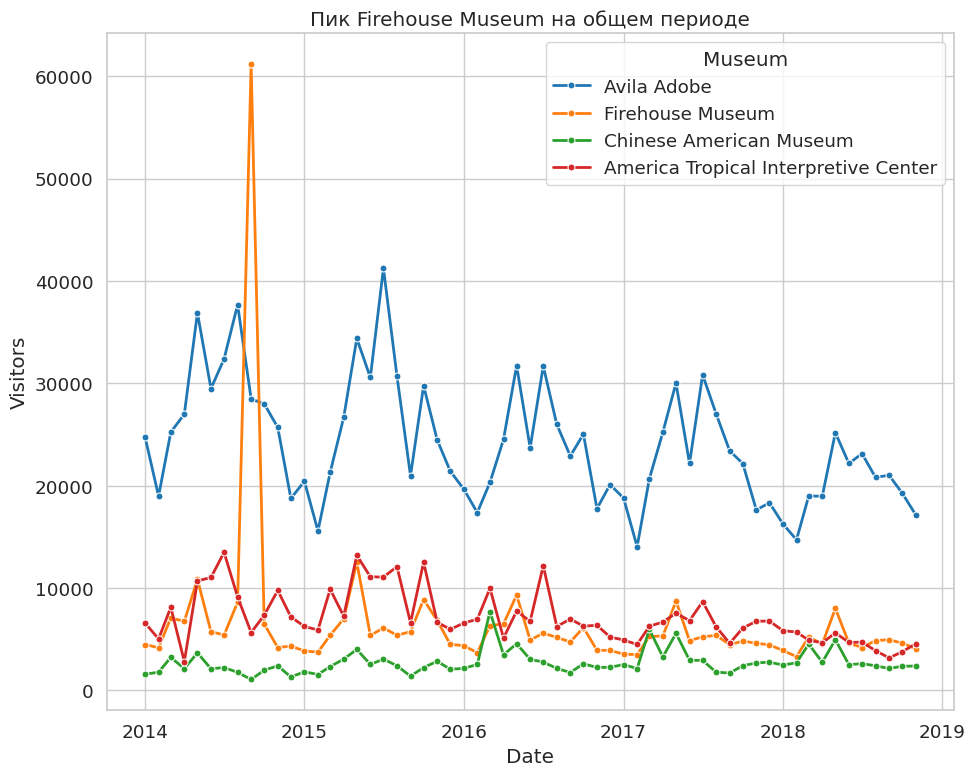

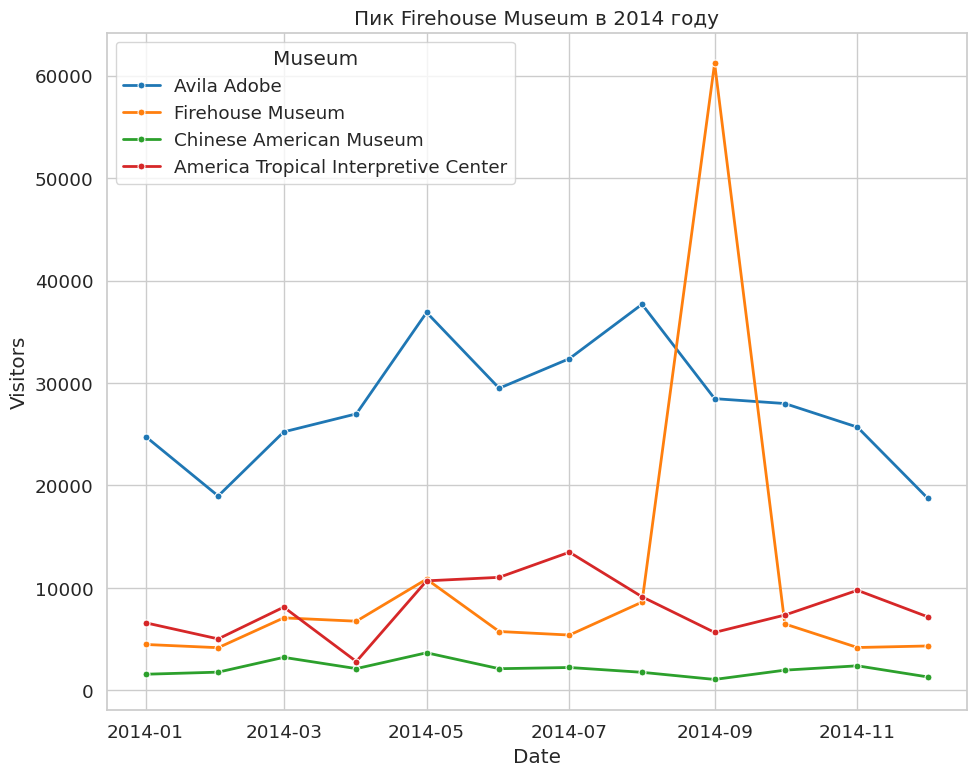

In [18]:
# Некий музей утверждает, что в 2014 году они провели мероприятие,
# которое привлекло невероятное количество посетителей, и что им следует получить дополнительный бюджет
# для проведения подобного мероприятия снова.

# Другие музеи считают, что такие мероприятия не так уж важны, и бюджеты должны быть разделены исключительно
# на основе недавних посетителей в среднем за месяц.

# Чтобы показать, как мероприятие соотносится с обычным трафиком в каждом музее, создайте необходимую диаграмму (какую?),
# которая показывает, как количество посетителей каждого музея менялось с течением времени.
def plot_line(data: pd.DataFrame, title: str, x: str = 'Date', y: str = 'Visitors', hue: str = 'Museum') -> None:
    plt.figure(figsize=(10, 8))
    sns.set_style('whitegrid')
    sns.set_context('notebook', font_scale=1.2)
    sns.lineplot(
        x=x,
        y=y,
        hue=hue,
        data=data,
        linewidth=2,
        marker='o',
        markersize=5,
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()
museums = museum_visitors.drop(columns='Date').columns.tolist()
melted_data = museum_visitors.melt(
    id_vars='Date',
    value_vars=museums,
    var_name='Museum',
    value_name='Visitors'
)
melted_data['Date'] = pd.to_datetime(melted_data['Date'])
melted_data_2014 = melted_data[melted_data['Date'].dt.to_period('Y') == pd.Period('2014', freq='Y')]
plot_line(melted_data, 'Пик Firehouse Museum на общем периоде')
plot_line(melted_data_2014, 'Пик Firehouse Museum в 2014 году')


2. Какой график вы выберете для визуализации ежемесячного трафика музеев?

**Ответ:**
Лайн чарт

3. Исходя из этого графика, какой музей проводил мероприятие по привлечению посетителей?

**Ответ:**
Firehouse Museum (оранжевый пик на графике)

4. Исходя из этого графика, какой музей обладает выраженной сезонностью посещения?

**Ответ:**
Avila Adobe (синяя линия) - на общем графике видны регулярные пики и спады с большой амплитудой от 15 до 40 тысяч посетителей в одно и то же время на протяжении нескольких лет

### Создание игры.

Ваши друзья решили создать свою собственную видеоигру! Вы - как аналитик данных, решили помочь ребятам. IGN Game Reviews собирает данные обо всех последних игровых релизах, а также о рейтинге, который они получили от экспертов, от 0 (катастрофа) до 10 (шедевр).

Вы решили использовать обзоры IGN для рекомендации дизайна будущей игры. К счастью, рейтинг уже обобщён в CSV-файле:

In [19]:
# загрузка данных для task № 2. Посмотрим на данные
ign_data = pd.read_csv('ign_scores.csv', index_col = 'Platform', sep = ',')
ign_data.head()

ign_data_melted = ign_data.reset_index().melt(
    id_vars='Platform',
    var_name='Genre',
    value_name='Score'
)
ign_data_pc = ign_data_melted[ign_data_melted['Platform'] == 'PC']
best_score = ign_data_pc.nlargest(1, 'Score').iloc[0]
print(f'Лучший жанр -> {best_score['Genre']}\nОценка -> {best_score['Score']:.2f}')

Лучший жанр -> RPG
Оценка -> 7.76


1. Какую самую высокую среднюю оценку получили игры для ПК (для любого жанра)?

**Ответ:**
Лучшая оценка 7.76 для жанра RPG

In [20]:
import matplotlib.pyplot as plt
import plotly.express as px
# Гоночная игра Mario Kart Wii, выпущенная для платформы Wii в 2008 году - отличная игра
# Её рейтинг составляет колоссальные 8,9! Вдохновленные успехом этой игры, вы подумываете о собственной гоночной игре
# для платформы Wii.

# Создайте столбчатую диаграмму (barplot), которая показывает средний балл гоночных игр для каждой платформы.
# Ваша диаграмма должна иметь по одному столбцу для каждой платформы.
racing_data = ign_data_melted[ign_data_melted['Genre'] == 'Racing'][['Platform', 'Score']].sort_values('Score', ascending=True)
fig = px.bar(
    data_frame=racing_data,
    x='Platform',
    y='Score',
    title='Средний рейтинг гоночных игр на различных платформах',
    color='Score',
    text='Score',
    color_continuous_scale='YlGnBu',
)
fig.update_layout(
    xaxis_title='Жанр',
    yaxis_title='Оценка',
    coloraxis_colorbar_title='Оценка'
)
fig.update_traces(texttemplate='%{text:.3f}')
fig.show()

2. На основе столбчатой диаграммы, ожидаете ли вы, что гоночная игра для платформы Wii получит высокий рейтинг? Если нет, то какая игровая платформа кажется лучшей альтернативой?

**Ответ:**
Нет, Mario Kart для Wii был скорее исключением из правил, так как является игрой про Марио :)

Средний балл гоночных игр для Wii составляет 5.01, что является самой низкой оценкой среди всех платформ. Наибольшего успеха при разработке игры получится добиться на Xbox One, где средний рейтинг составляет 8.16

In [21]:
# В конце концов, вы решаете не создавать гоночную игру для Wii
# Вы решаете использовать всевозможные данные IGN, чтобы определиться с новым выбором жанра и платформы.

# Используйте данные для создания тепловой карты среднего балла по жанру и платформе. (для sns.heatmap исп. доп. annot = True)
fig = px.imshow(
        ign_data,
        color_continuous_scale='YlGnBu',
        labels=dict(color='Score')
    )
fig.update_layout(
    width=1000,
    height=700,
    margin=dict(l=0, r=0, t=40, b=0),
    title='Средние оценки игр по платформам и жанрам',
    xaxis_title = 'Жанр',
    yaxis_title = 'Платформа'
)
fig.update_coloraxes(
    colorbar_title='Оценка'
)

fig.show()

3. Какая комбинация жанра и платформы получает самые высокие средние оценки?

**Ответ:**
Самые высокие средние оценки получает комбинация Playstation 4 <-> Simulation с рейтингом 9.25

4. А какая комбинация получает самые низкие средние оценки?

**Ответ:**
Самые низкие оценки получают комбинации Game Boy Color с жанрами файтинг и шутер с рейтингом 4.5

### Сладости в данных.

Вы работаете на крупного производителя сладостей, и ваша цель — написать отчет, который ваша компания может использовать для разработки своего следующего продукта. Вскоре после начала исследования вы натыкаетесь на этот очень интересный набор данных, содержащий результаты опроса по потреблению любимых сладостей.

In [22]:
# загрузка данных для task № 3. Посмотрим на данные
candy_data = pd.read_csv('candy.csv', index_col = 'id', sep = ',')
candy_data.head(15)

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
id,,,,,,,,,,,,,
0,100 Grand,Yes,No,Yes,No,No,Yes,No,Yes,No,0.732,0.860,66.971725
1,3 Musketeers,Yes,No,No,No,Yes,No,No,Yes,No,0.604,0.511,67.602936
2,Air Heads,No,Yes,No,No,No,No,No,No,No,0.906,0.511,52.341465
3,Almond Joy,Yes,No,No,Yes,No,No,No,Yes,No,0.465,0.767,50.347546
4,Baby Ruth,Yes,No,Yes,Yes,Yes,No,No,Yes,No,0.604,0.767,56.914547
5,Boston Baked Beans,No,No,No,Yes,No,No,No,No,Yes,0.313,0.511,23.417824
6,Candy Corn,No,No,No,No,No,No,No,No,Yes,0.906,0.325,38.010963
7,Caramel Apple Pops,No,Yes,Yes,No,No,No,No,No,No,0.604,0.325,34.517681
8,Charleston Chew,Yes,No,No,No,Yes,No,No,Yes,No,0.604,0.511,38.975037


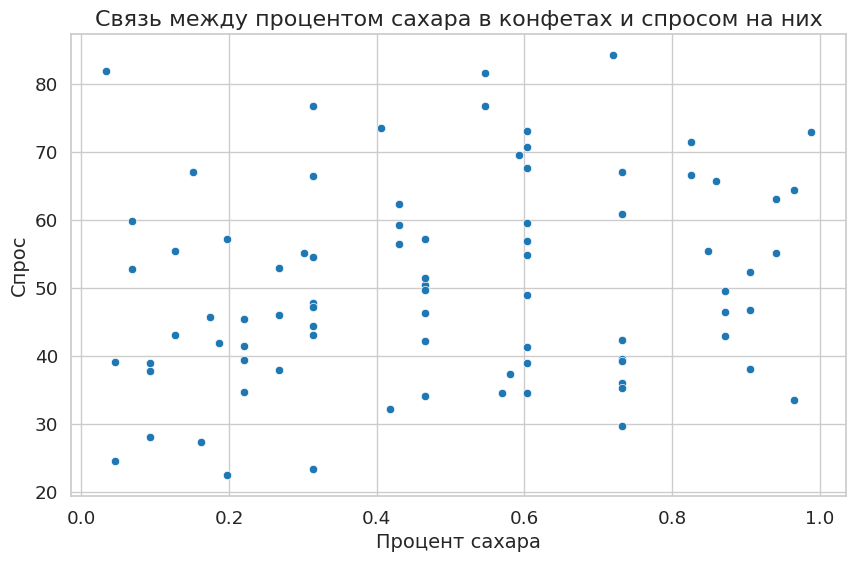

In [23]:
# Чем больше сахара - тем вкуснее?

# Создайте диаграмму рассеяния (scatter plot), которая показывает связь между «sugarpercent» (на горизонтальной оси x)
# и «winpercent» (на вертикальной оси y).

plt.figure(figsize=(10,6))
sns.scatterplot(
    x='sugarpercent',
    y='winpercent',
    data=candy_data
    )
plt.title('Связь между процентом сахара в конфетах и спросом на них', fontsize=16)
plt.xlabel('Процент сахара', fontsize=14)
plt.ylabel('Спрос', fontsize=14)

plt.show()

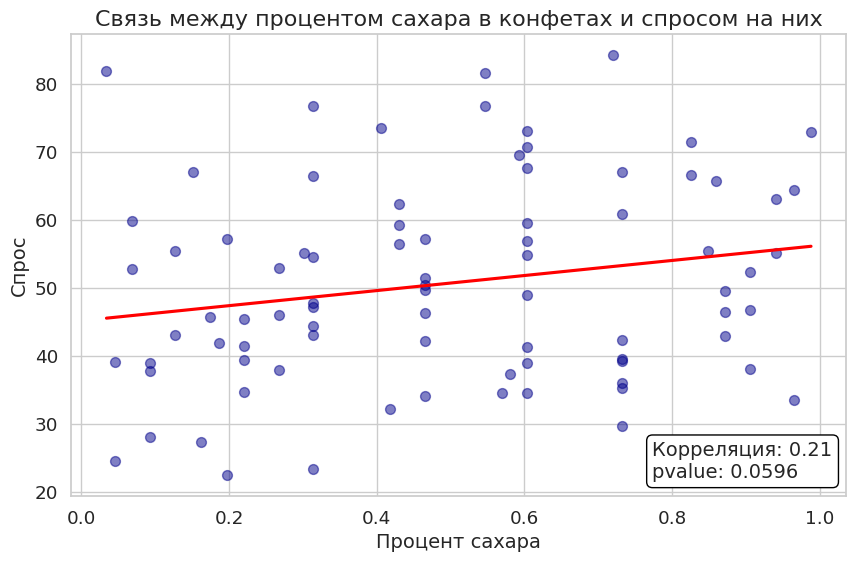

In [24]:
# Похоже, что только диаграммы рассеяния недостаточно, давайте построим её с линией регресси (regplot).
# Согласно графику который вы получите, есть ли небольшая корреляция между 'winpercent' и 'sugarpercent'?
# Что это говорит вам о конфетах, которые люди предпочитают?

from scipy.stats import pearsonr

corr_coef, pvalue = pearsonr(candy_data['sugarpercent'], candy_data['winpercent'])
plt.figure(figsize=(10,6))
sns.regplot(
    x='sugarpercent',
    y='winpercent',
    data=candy_data,
    scatter_kws={
        'color': 'darkblue',
        's': 50,
        'alpha': 0.5
    },
    line_kws={
        'color': 'red'
    },
    ci=None
)
plt.text(
    0.75,
    0.12,
    s=f'Корреляция: {corr_coef:.2f}\npvalue: {pvalue:.4f}',
    transform=plt.gca().transAxes, fontsize=14, verticalalignment='top',
    bbox=dict(boxstyle='round, pad=0.3', edgecolor='black', facecolor='white')
)
plt.title('Связь между процентом сахара в конфетах и спросом на них', fontsize=16)
plt.xlabel('Процент сахара', fontsize=14),
plt.ylabel('Спрос', fontsize=14)
plt.show()

1. Ответьте в свободном формате, на основании построенных графиков: **есть ли какая-то связь между предпочтениями покупателей и количеством сахара в сладостях?**

**Ответ:**
Корреляция спроса и процента сахара очень незначительно влияет на покупку -> с ростом сахара немного увеличивается шанс того, что сладость купят. Однако, если взять во внимание pvalue = 0.0596 > 0.05 и крайне хаотичный характер разброса точек по графику - есть абсолютно противоположные значения по спросу относительно линии регрессора, но у них одинаковый процент сахара, так и одинаковые значения спроса на совсем разных значениях сахара. В общем можно сказать, что покупатели не обращают внимание на содержание сахара при покупке конфет.

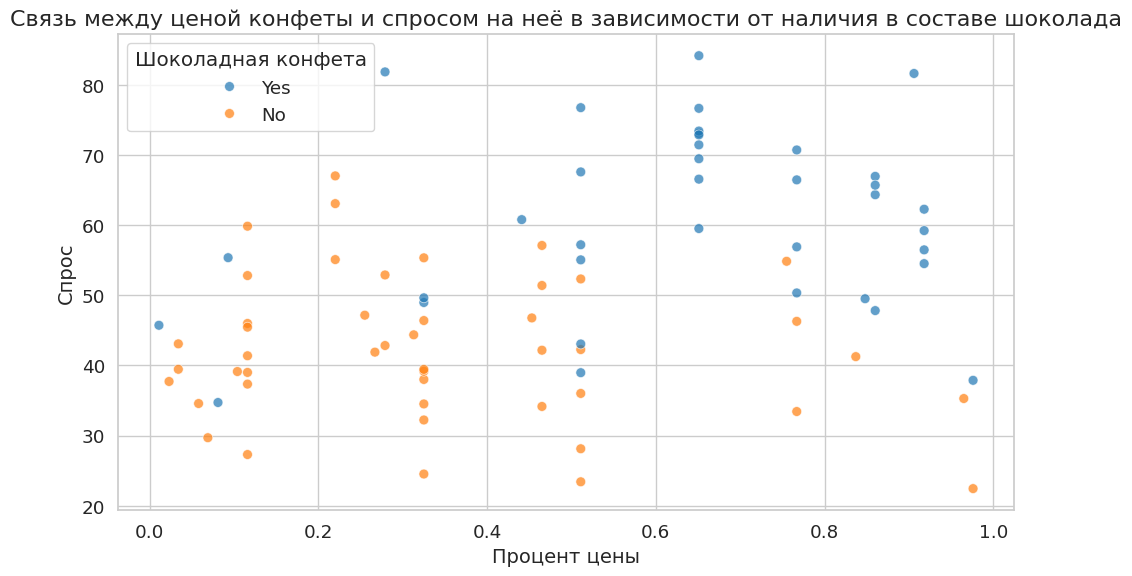

In [25]:
# Ниже создайте диаграмму рассеяния, чтобы показать связь между «pricepercent» (на горизонтальной оси x)
# и «winpercent» (на вертикальной оси y). Используйте столбец «chocolate» для цветовой кодировки точек.

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=candy_data,
    x='pricepercent',
    y='winpercent',
    hue='chocolate',
    alpha=0.7,
    s=50
)
plt.title('Связь между ценой конфеты и спросом на неё в зависимости от наличия в составе шоколада', fontsize=16)
plt.xlabel('Процент цены', fontsize=14)
plt.ylabel('Спрос', fontsize=14)
plt.legend(title='Шоколадная конфета')
plt.tight_layout()
plt.show()

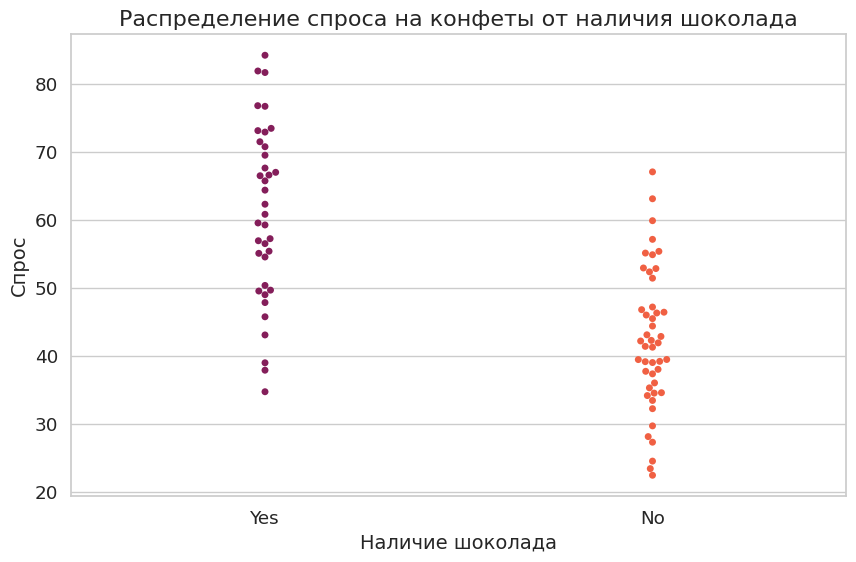

In [26]:
# Теперь давайте построим категориальную диаграмму рассеяния (график роя - swarmplot),
# чтобы подчеркнуть связь между «chocolate» и «winpercent».
# Поместите «chocolate» на (горизонтальную) ось x, а «winpercent» на (вертикальную) ось y.
import warnings
warnings.filterwarnings('ignore')


plt.figure(figsize=(10,6))
sns.swarmplot(
    data=candy_data,
    x='chocolate',
    y='winpercent',
    palette='rocket'
)
plt.title('Распределение спроса на конфеты от наличия шоколада', fontsize=16)
plt.xlabel('Наличие шоколада', fontsize=14)
plt.ylabel('Спрос', fontsize=14)
plt.show()

2. Ответьте в свободном формате, на основании построенных графиков: **Как наличие шоколада влияет на предпочтения покупателей? Какой график лучше характеризует это: swarmplot или scatter plot?**

**Ответ:**
Покупатели куда активнее обращают на шоколадные конфеты. Как на диаграмме рассеяния, так и на swarmplot можно увидеть преобладание шоколадных конфет перед нешоколадными. На scatter plot отчетливо видно, что шоколадные конфеты стоят больше и обладают большим спросом. На Swarm plot спрос на нешоколадные конфеты начинается от 22 и достигает максимума на 67 пунктах, в то же время шоколадные конфеты начинаются с 33 и доходит до 85 пунктов, что прекрасно показывает, что покупатели любят брать конфеты с шоколадом.

### Знаменитые Ирисы.

В набор представленных датасетов содержится показательный набор данных о замерах геометрических размеров Ирисов различных видов:
- Iris setosa
- Iris versicolor
- Iris virginica

Найдите датасет iris.csv и импортируйте для анализа в dataframe. Используйте любые графики для визуализации, чтобы ответить на вопрос:

- *Какой вид Ирисов можно определить (отделить от других видов) используя всего лишь один параметр? (и какой параметр)*

In [27]:
iris_data = pd.read_csv('iris.csv', index_col='Id')
iris_data.info()
iris_data.head()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 1 to 150
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Sepal Length (cm)  150 non-null    float64
 1   Sepal Width (cm)   150 non-null    float64
 2   Petal Length (cm)  150 non-null    float64
 3   Petal Width (cm)   150 non-null    float64
 4   Species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 7.0+ KB


,Sepal Length (cm),Sepal Width (cm),Petal Length (cm),Petal Width (cm),Species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa


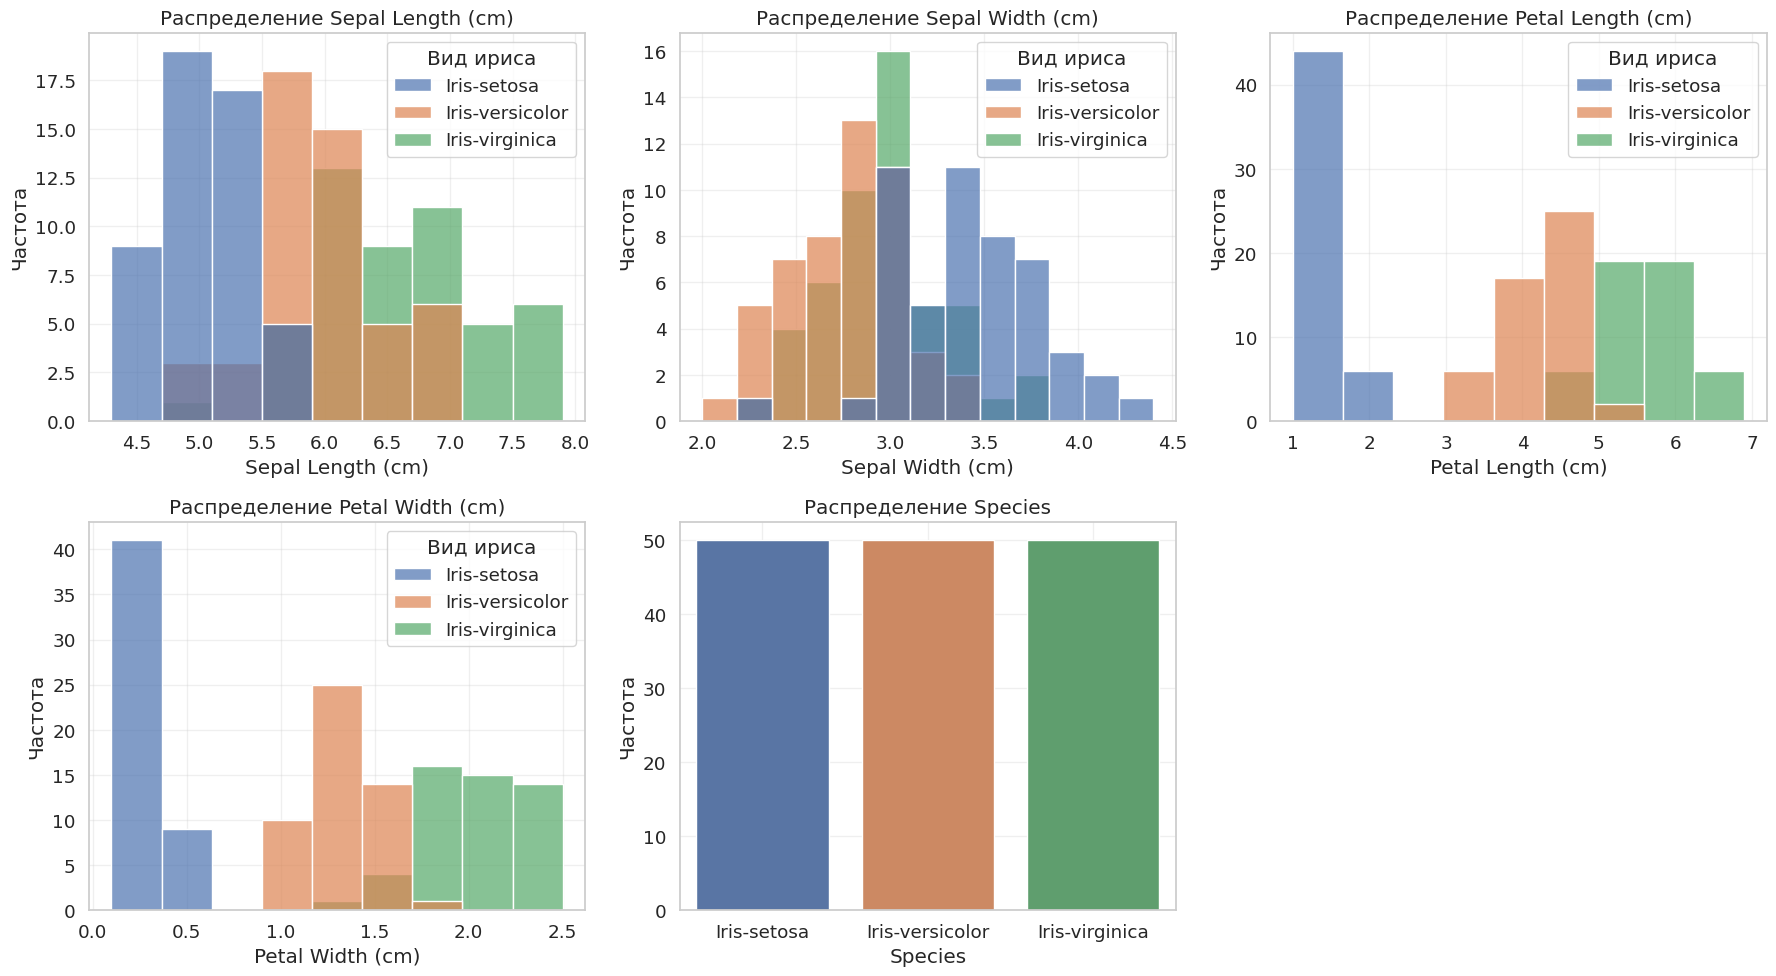

In [28]:
import numpy as np
def plot_dist(df: pd.DataFrame) -> None:
    num_cols = df.shape[1]
    num_rows = (num_cols + 2) // 3
    plt.figure(figsize=(18, 5*num_rows))
    for i, column in enumerate(df.columns):
        plt.subplot(num_rows, 3, i+1)
        if np.issubdtype(df[column].dtype, np.number):
            sns.histplot(
                data=df,
                x=column,
                hue='Species',
                palette='deep',
                multiple='layer',
                alpha=0.7
            )
            legend = plt.gca().get_legend()
            if legend:
                legend.set_title('Вид ириса')
        else:
            sns.countplot(
                data=df,
                x=column,
                palette='deep'
            )
        plt.grid(True, alpha=0.3)
        plt.xlabel(column)
        plt.ylabel('Частота')
        plt.title(f'Распределение {column}')
    plt.tight_layout()
    plt.show()
plot_dist(iris_data)

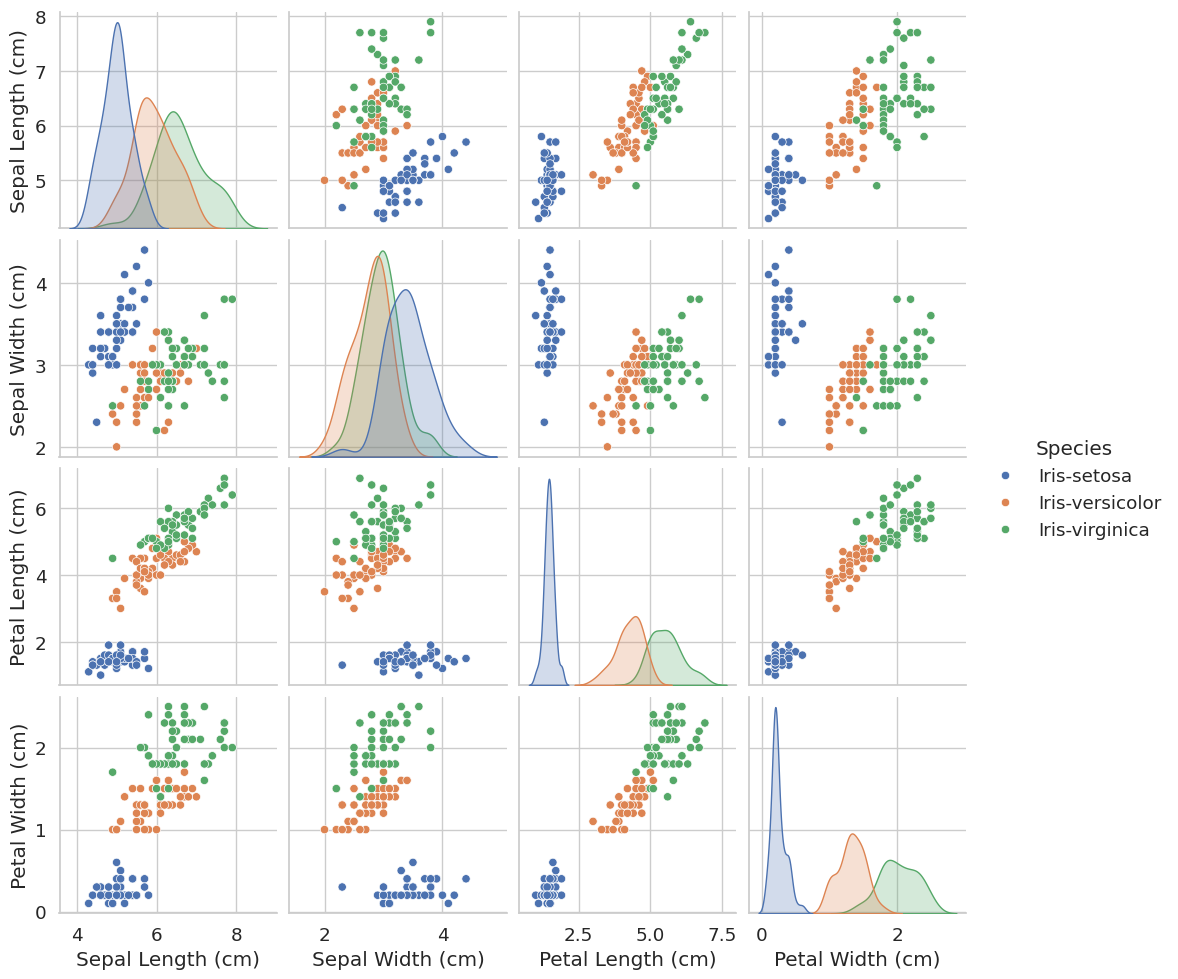

In [29]:
sns.pairplot(
    data=iris_data,
    hue='Species',
    palette='deep',
)

На каждом сопоставлении Pair Plot Видно, что значения Iris-setosa выбиваются от общих значений.

*Какой вид Ирисов можно определить (отделить от других видов) используя всего лишь один параметр? (и какой параметр)*

*Ответ:*
Для четкого выделения параметра достаточно рассмотреть визуализацию распределения параметров с цветовым разделениям по виду ириса. Достаточно посмотреть на Petal Length или Petal Width - в них iris-setosa имеет сильно выделяющиемя значения. Iris-setosa единственный имеет длину лепестка, преимущественно равную 1 см, иногда вырастает до 2 см, в то же время iris-versicolor имеет минимальную длину лепестка 3 см, а iris-virginica 4,5 см, то есть распределение Iris-setosa выбивается из распределений других видов. Аналогично с шириной липестка -> iris-setosa преимущественно 0.3 см, иногда доходит до 0.6 см, минимум iris-versicolor равен 0.9 см, минимум iris-virginica равен 1.2 см. На Pair plot так же отчетливо видно, что iris-setosa слишком сильно выделяется по сравнению с другими.